# Visualization Experiments

Ad-hoc notebook for GIF/storyboard enhancements, uncertainty ribbons, and comparison layouts.

## Updated Visualization Tips
- dacs_time_series now records uncertainty bands when you run the pipeline with --uncertainty-samples N.
- Generate GIFs with python -m analytics.visualize_dacs --game_id ... --play_id ... --json_dir analytics/outputs/dacs to see the ribbons.
- Use this notebook for quick side-by-side plots or to prototype new overlays before codifying them in 
isualize_dacs.py.

## Choose Plays

In [6]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()

def resolve_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for candidate in candidates:
        analytics_dir = candidate / 'analytics'
        if analytics_dir.is_dir():
            return candidate
        if candidate.name == 'analytics' and candidate.is_dir():
            return candidate.parent
    raise FileNotFoundError(f'Could not locate analytics/ directory when starting from {start}')

REPO_ROOT = resolve_repo_root(NOTEBOOK_DIR)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Using analytics repo at:', REPO_ROOT)

outputs_dir = REPO_ROOT / 'analytics' / 'outputs' / 'dacs'


def load_play_data(game_id: int, play_id: int) -> dict:
    path = outputs_dir / f"game_{game_id}_play_{play_id}.json"
    if not path.exists():
        raise FileNotFoundError(f'Missing play JSON at {path}')
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    print(f"Loaded play {game_id}_{play_id} from {path.relative_to(REPO_ROOT)}")
    return payload

DEFAULT_GAME = 2023090700
DEFAULT_PLAY = 4041
print('Using default play for single-play visualizations:', DEFAULT_GAME, DEFAULT_PLAY)
data = load_play_data(DEFAULT_GAME, DEFAULT_PLAY)


Using analytics repo at: c:\Users\16476\big_data_bowl
Using default play for single-play visualizations: 2023090700 4041
Loaded play 2023090700_4041 from analytics\outputs\dacs\game_2023090700_play_4041.json


## Time-Series Plot with Bands

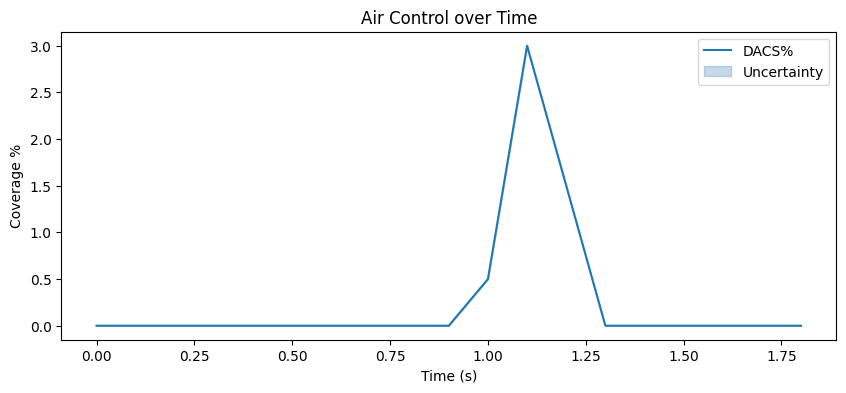

In [7]:
df = pd.DataFrame({
    't': [i * data['dt'] for i in range(len(data['dacs_series']))],
    'dacs': data['dacs_series'],
    'dacs_lo': data.get('dacs_series_lo', data['dacs_series']),
    'dacs_hi': data.get('dacs_series_hi', data['dacs_series']),
})
plt.figure(figsize=(10,4))
plt.plot(df['t'], df['dacs'], label='DACS%')
plt.fill_between(df['t'], df['dacs_lo'], df['dacs_hi'], color='steelblue', alpha=0.3, label='Uncertainty')
plt.xlabel('Time (s)')
plt.ylabel('Coverage %')
plt.title('Air Control over Time')
plt.legend()
plt.show()

## Player Share Bar Chart

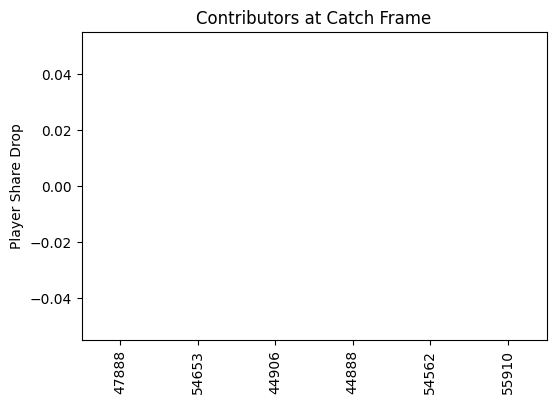

In [8]:
ps = pd.Series(data['player_share_at_T']).sort_values(ascending=False)
plt.figure(figsize=(6,4))
ps.plot(kind='bar')
plt.ylabel('Player Share Drop')
plt.title('Contributors at Catch Frame')
plt.show()

## Multi-Play Comparison
Visualize two or more plays side-by-side to compare DACS bands, final values, and outcome probabilities.

Loaded play 2023090700_4041 from analytics\outputs\dacs\game_2023090700_play_4041.json
Loaded play 2023090700_1588 from analytics\outputs\dacs\game_2023090700_play_1588.json


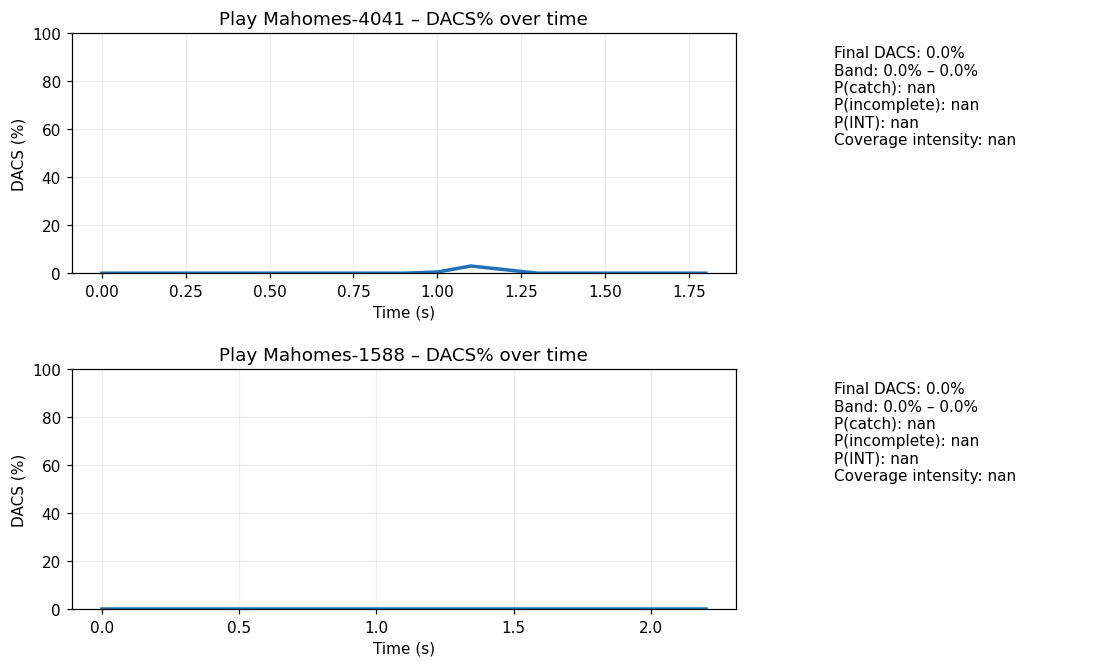

,label,game_id,play_id,dacs_final,dacs_lo,dacs_hi,p_catch,p_incomplete,p_int
0,Mahomes-4041,2023090700,4041,None,None,None,None,None,None
1,Mahomes-1588,2023090700,1588,None,None,None,None,None,None


In [9]:

from matplotlib import gridspec


def plot_dacs_comparison(play_keys, labels=None):
    labels = labels or [f"{gid}_{pid}" for gid, pid in play_keys]
    n = len(play_keys)
    fig = plt.figure(figsize=(12, 3.4 * n), dpi=110)
    gs = gridspec.GridSpec(nrows=n, ncols=2, width_ratios=[2.5, 1], hspace=0.4)
    summary_rows = []
    for idx, (play_key, label) in enumerate(zip(play_keys, labels)):
        game_id, play_id = play_key
        pdata = load_play_data(game_id, play_id)
        t = [i * pdata['dt'] for i in range(len(pdata['dacs_series']))]
        ax_ts = fig.add_subplot(gs[idx, 0])
        dacs_lo = pdata.get('dacs_series_lo', pdata['dacs_series'])
        dacs_hi = pdata.get('dacs_series_hi', pdata['dacs_series'])
        ax_ts.fill_between(t, dacs_lo, dacs_hi, color='#c6dbef', alpha=0.5)
        ax_ts.plot(t, pdata['dacs_series'], color='#2171b5', lw=2.3)
        ax_ts.set_title(f"Play {label} – DACS% over time")
        ax_ts.set_xlabel('Time (s)')
        ax_ts.set_ylabel('DACS (%)')
        ax_ts.set_ylim(0, 100)
        ax_ts.grid(True, alpha=0.2)

        ax_metrics = fig.add_subplot(gs[idx, 1])
        probs = pdata.get('event_probabilities', {})
        metrics_text = "\n".join([
            f"Final DACS: {pdata.get('dacs_final', 0):.1f}%",
            f"Band: {pdata.get('dacs_final_lo', 0):.1f}% – {pdata.get('dacs_final_hi', 0):.1f}%",
            f"P(catch): {probs.get('catch', float('nan')):.2f}",
            f"P(incomplete): {probs.get('incomplete', float('nan')):.2f}",
            f"P(INT): {probs.get('interception', float('nan')):.2f}",
            f"Coverage intensity: {pdata.get('coverage_intensity', float('nan')):.2f}",
        ])
        ax_metrics.text(0.02, 0.95, metrics_text, va='top', ha='left', fontsize=10)
        ax_metrics.axis('off')

        summary_rows.append({
            'label': label,
            'game_id': game_id,
            'play_id': play_id,
            'dacs_final': pdata.get('dacs_final'),
            'dacs_lo': pdata.get('dacs_final_lo'),
            'dacs_hi': pdata.get('dacs_final_hi'),
            'p_catch': probs.get('catch'),
            'p_incomplete': probs.get('incomplete'),
            'p_int': probs.get('interception'),
        })

    plt.show()
    display(pd.DataFrame(summary_rows))


plot_dacs_comparison([(2023090700, 4041), (2023090700, 1588)], labels=['Mahomes-4041', 'Mahomes-1588'])


## Exporting GIFs via visualize_dacs.py
Once satisfied with the experiments above, generate the polished GIF directly from the CLI. Example:
`ash
python -m analytics.visualize_dacs \
  --game_id 2023090700 --play_id 4041 \
  --json_dir analytics/outputs/dacs \
  --out_dir analytics/outputs/gifs
`
(The script names the GIF game_<game>_play_<play>.gif inside --out_dir.)
Use --uncertainty-samples when producing the JSONs so the ribbons match the plots in this notebook.

In [11]:
# Example: trigger GIF generation for the default play
import subprocess, sys
print('Use CLI from terminal instead; cell left as example only.')([
    sys.executable,
    '-m', 'analytics.visualize_dacs',
    '--game_id', str(DEFAULT_GAME),
    '--play_id', str(DEFAULT_PLAY),
    '--json_dir', 'analytics/outputs/dacs',
    '--out_dir', 'analytics/outputs/gifs'
], check=True)


CalledProcessError: Command '['c:\\Python310\\python.exe', '-m', 'analytics.visualize_dacs', '--game_id', '2023090700', '--play_id', '4041', '--json_dir', 'analytics/outputs/dacs', '--out_dir', 'analytics/outputs/gifs']' returned non-zero exit status 1.